In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

/home/merlin/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Read in all the words

words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [5]:
# Build the vocabulary of characters and mappings to/from integers

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [27]:
# Bulld the dataset
block_size = 3    # Context length: How many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]    # Crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])    # 80%
Xdev, Ydev = build_dataset(words[n1:n2])    # 10%
Xte, Yte = build_dataset(words[n2:])    # 10%


torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [55]:
# MLP revisited
n_embd = 10    # Dimensionality of the character embedding vectors
n_hidden = 200    # The number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)    # For reproducibility
C = torch.randn((vocab_size, n_embd),              generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden),  generator=g) * (5/3)/(n_embd * block_size)**0.5  #0.2
b1 = torch.randn(n_hidden,                         generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),           generator=g) * 0.01
b2 = torch.randn(vocab_size,                       generator=g) * 0

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))    # Numbers of parameters in total
for p in parameters:
    p.requires_grad = True

12297


tensor(-0.0133) tensor(0.9908)
tensor(-0.0041) tensor(3.1088)


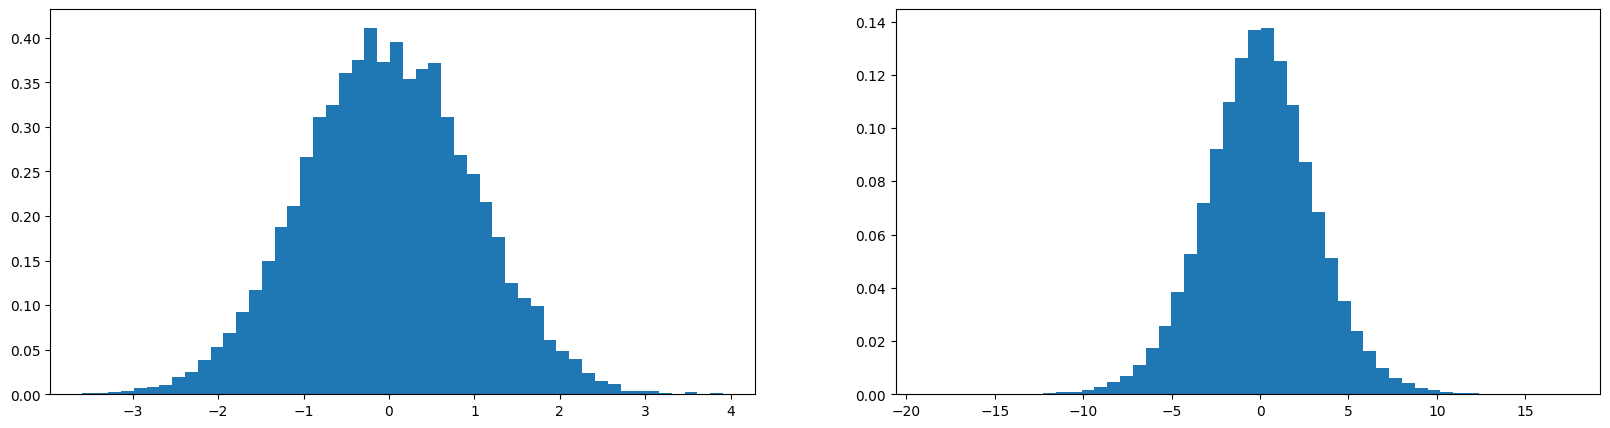

In [40]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True);

In [47]:
hpreact.mean(0, keepdim=True).shape

torch.Size([1, 200])

In [73]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2817


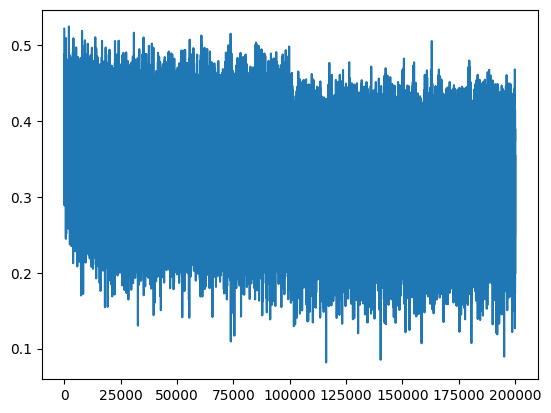

In [19]:
plt.plot(lossi)

In [57]:
# Calibrate the batch norm at the end of training

with torch.no_grad():
    # Pass training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # Measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)


In [58]:
bnmean

tensor([[-2.1171,  0.5151, -1.0355,  1.1472,  0.6457,  0.3297,  1.8942, -0.4451,
          0.7888,  2.1818, -2.5897, -2.1385, -0.5529, -0.8029, -0.5847, -0.7731,
          0.3468, -1.7540, -0.5940,  1.5619, -0.5667, -0.2291, -0.3648,  0.2870,
          1.2614,  1.7647,  1.3128,  0.3417,  1.0104,  1.6196, -0.6550, -0.9392,
          0.7127, -0.2060,  0.4415, -0.9259, -1.5156,  0.2045,  0.0871,  0.9062,
          0.1703, -1.0021, -0.5580, -0.1233,  0.8608,  0.2528,  0.9942, -1.4480,
          2.0848,  1.2254,  1.4297,  0.1473,  2.2827,  0.7296,  0.9589, -2.5080,
         -0.3612,  0.7973,  2.2360, -1.4968, -0.2657,  0.9916,  0.8040,  0.4386,
          1.2355,  1.3860, -0.2402,  1.4185, -0.5125, -0.2784,  0.0867,  0.6063,
          0.6206, -1.8870, -2.3069,  0.4171,  1.2391, -0.0953,  0.2780,  0.4433,
         -0.2146,  1.2355,  1.2541,  1.0807,  0.3930, -0.6237, -0.8048, -0.0700,
          2.7139, -0.2097, -0.9276,  1.2881, -0.9340, -1.0923, -1.5613,  0.5643,
         -0.1310, -0.3506, -

In [59]:
bnmean_running

tensor([[-2.1052,  0.5062, -1.0491,  1.1578,  0.6407,  0.3288,  1.9093, -0.4267,
          0.7898,  2.1971, -2.5673, -2.1399, -0.5380, -0.8096, -0.5738, -0.7688,
          0.3398, -1.7605, -0.5851,  1.5558, -0.5555, -0.2153, -0.3661,  0.2812,
          1.2575,  1.7619,  1.3153,  0.3318,  1.0108,  1.6235, -0.6543, -0.9489,
          0.7128, -0.2062,  0.4278, -0.9170, -1.5013,  0.2251,  0.0678,  0.9039,
          0.1809, -0.9840, -0.5668, -0.1117,  0.8465,  0.2390,  0.9985, -1.4425,
          2.0987,  1.2389,  1.4190,  0.1478,  2.2976,  0.7490,  0.9491, -2.4884,
         -0.3599,  0.7966,  2.2169, -1.4949, -0.2631,  0.9898,  0.8070,  0.4637,
          1.2417,  1.3894, -0.2368,  1.4214, -0.5096, -0.2794,  0.0982,  0.5819,
          0.6432, -1.8995, -2.3053,  0.4097,  1.2177, -0.1014,  0.2751,  0.4427,
         -0.2150,  1.2323,  1.2708,  1.0634,  0.3814, -0.6506, -0.8102, -0.0687,
          2.7042, -0.2174, -0.9457,  1.2814, -0.9254, -1.0830, -1.5526,  0.5789,
         -0.1294, -0.3462, -

In [61]:
@torch.no_grad()    # This decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    emb = C[x]    # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)    # Concat into (N, block_size * n_embd)
    hpreact = embcat @ W1 + b1 # Hidden layer pre-activation
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
    h = torch.tanh(embcat @ W1 + b1)    # (N, n_hidden)
    logits = h @ W2 + b2    # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 3.093360185623169
val 3.131377696990967


```
Loss Log

Original:
train 2.12
val 2.16

Fix softmax confidently wrong:
train 2.07
val 2.13

Fix tanh layer too saturated at init:
train 2.03
val 2.10

Use a semi-principled "kaiming init" instead of hacky init:
train 2.03
val 2.16

Add a batch norm layer
train 3.09
val 3.13
```

In [13]:
# Sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size    # Initialize with all ...
    while True:
        # Forward pass the NN
        emb = C[torch.tensor([context])]    # (1,block_size,n_embd)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        # Sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # Shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # If we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))    # Decode and print the generated word

carlah.
amille.
khi.
myli.
taty.
skanden.
jazhubedhelsyn.
jarqui.
nellara.
chaiir.
kaleigh.
ham.
jorn.
quintis.
lin.
alianni.
wazthoniearynix.
kaelisselize.
demiia.
gian.


# ------- SUMMARY ------------

In [80]:

class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  #layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


In [81]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.3313


layer 2 (      Tanh): mean -0.00, std 0.64, saturated: 2.56%
layer 5 (      Tanh): mean -0.00, std 0.64, saturated: 2.25%
layer 8 (      Tanh): mean +0.00, std 0.64, saturated: 2.03%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 2.00%
layer 14 (      Tanh): mean +0.00, std 0.65, saturated: 1.44%


Text(0.5, 1.0, 'activation distribution')

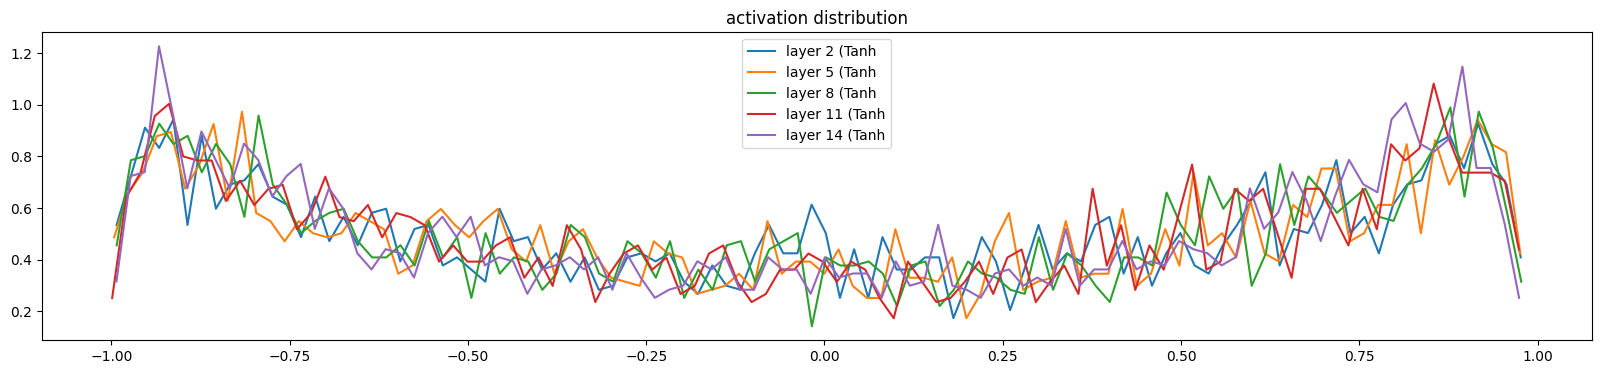

In [82]:
# Visualize histograms
plt.figure(figsize=(20, 4)) # Width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):    # Note: Exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std 3.117992e-03
layer 5 (      Tanh): mean +0.000000, std 2.528797e-03
layer 8 (      Tanh): mean -0.000000, std 2.317136e-03
layer 11 (      Tanh): mean +0.000000, std 2.106393e-03
layer 14 (      Tanh): mean -0.000000, std 2.026949e-03


Text(0.5, 1.0, 'gradient distribution')

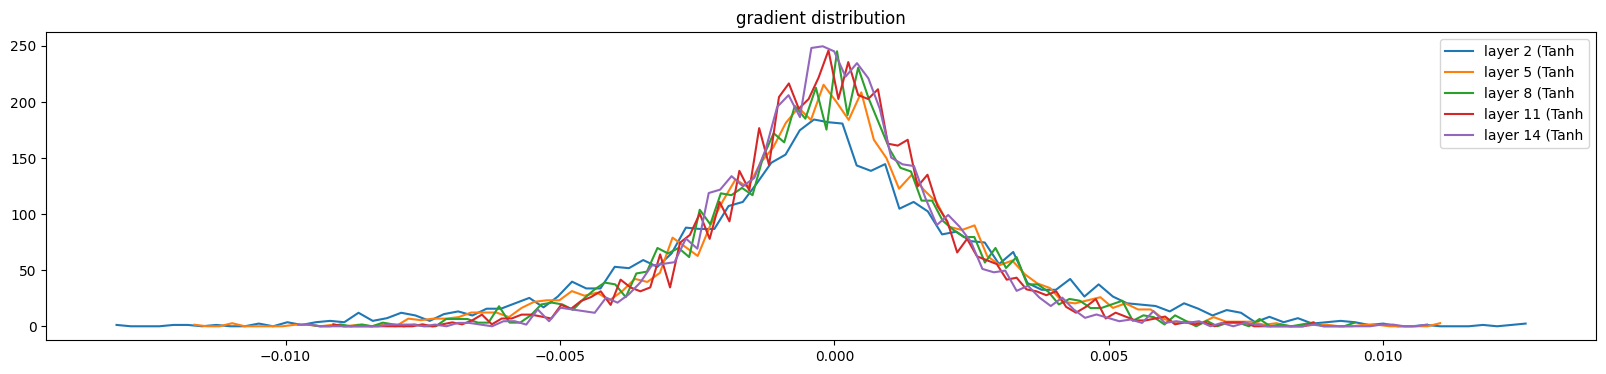

In [83]:
# Visualize histograms
plt.figure(figsize=(20, 4))    # Width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]):    # Note: Exclude the output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 1.000441e-02 | grad:data ratio 9.994517e-03
weight  (30, 100) | mean -0.000162 | std 1.097191e-02 | grad:data ratio 5.795948e-02
weight (100, 100) | mean -0.000029 | std 8.503919e-03 | grad:data ratio 8.314791e-02
weight (100, 100) | mean +0.000117 | std 6.979925e-03 | grad:data ratio 6.807298e-02
weight (100, 100) | mean +0.000025 | std 6.375992e-03 | grad:data ratio 6.260219e-02
weight (100, 100) | mean -0.000051 | std 6.253165e-03 | grad:data ratio 6.146757e-02
weight  (100, 27) | mean -0.000062 | std 1.320229e-02 | grad:data ratio 1.269270e-01


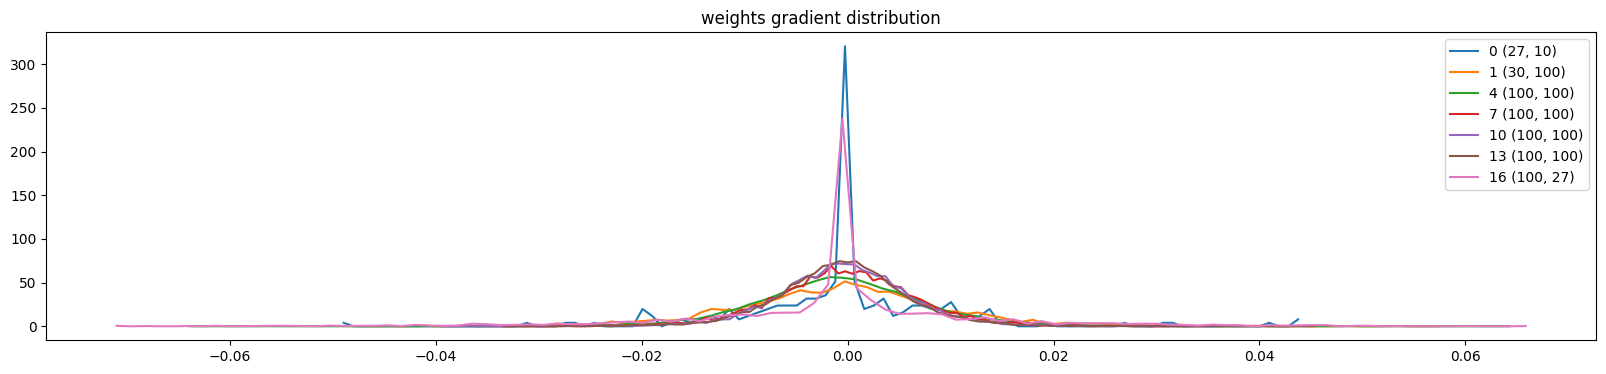

In [84]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

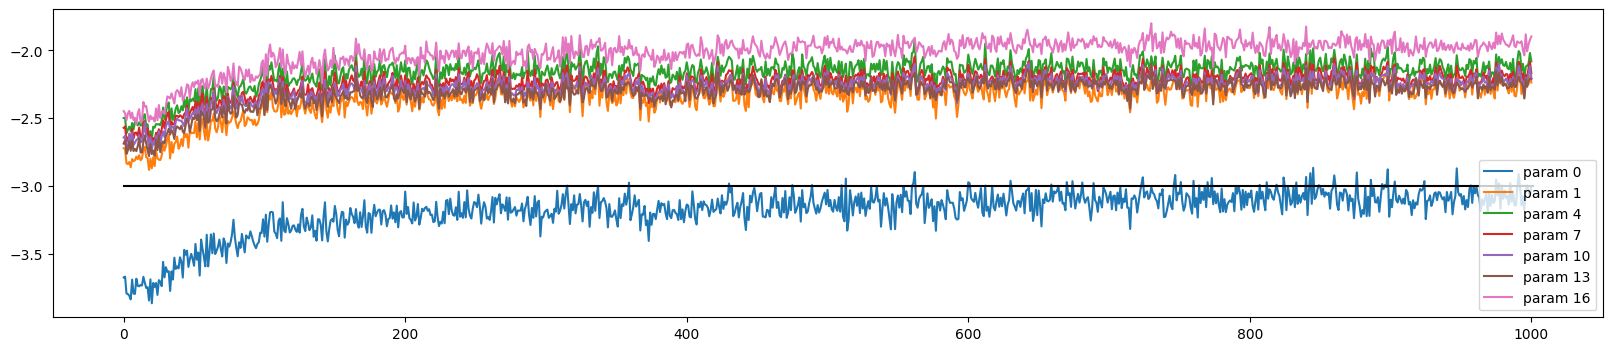

In [85]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);